# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [70]:
import pandas as pd
import numpy as np

#Gerando valores
ud = np.random.normal(0,4,1000)
ud

array([-4.46482197e+00, -8.07829578e+00,  6.56440938e-01, -3.56606302e+00,
       -3.68893827e-01, -5.43087020e-01, -3.97352020e+00, -4.26763611e+00,
       -5.92195416e+00,  4.32873522e+00, -5.98585097e-01,  8.21241305e-01,
        2.16387105e+00, -5.75225753e+00, -4.45438568e-01, -7.38289813e-02,
       -8.58169293e-01,  1.58125200e+00, -1.73255876e+00,  6.82608348e+00,
       -1.07253806e+01,  4.50782866e+00, -1.89654032e+00, -2.22649940e+00,
        3.72127475e+00,  6.53555583e+00,  1.47947244e+00,  4.55484551e+00,
        4.64782565e+00, -2.25092368e+00, -3.76291509e+00,  5.70248696e+00,
        6.90601021e-01,  4.79753554e+00,  5.56252284e-01, -1.97202169e+00,
       -3.67505409e+00, -1.48824279e-01, -1.41750846e+00, -6.56014279e+00,
        2.12284425e+00,  1.09136151e+00,  5.45475090e-01, -2.32359729e+00,
       -1.48744414e+00,  3.93612202e+00, -1.91744266e+00, -5.81413525e+00,
       -1.82652325e+00, -1.53254882e+00,  2.08134141e+00, -4.23899481e+00,
       -3.30025436e+00, -

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [71]:
#Criando 1000 genes
genes = np.random.randint(1000, size = 1000)

#Criando 1000 pacientes
df = pd.DataFrame(index= [f"Paciente {i}" for i in range(1, 1001)])

df["#Genes"] = genes
df["Expressão"] = ud
df

,#Genes,Expressão
Paciente 1,304,-4.464822
Paciente 2,525,-8.078296
Paciente 3,159,0.656441
Paciente 4,699,-3.566063
Paciente 5,551,-0.368894
...,...,...
Paciente 996,315,0.813733
Paciente 997,151,5.875102
Paciente 998,437,3.820632
Paciente 999,912,-7.218535


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Irei categorizar os dados baseado no nível de expressão gênica

Abaixo de -2.0 -> Inibição Forte

-2.0 até -0.5 -> Inibição Leve

-0.5 até 0.5 -> Expressão Basal

0.5 até 2.0 -> Expressão Moderada

2.0 até 5.0 -> Expressão Alta  

Acima de 5.0 -> Super-Expressão

In [72]:
bins = [-np.inf, -5, -1.5, 1.5, 5, 8, np.inf]

labels = [
    'Inibição Severa',
    'Expressão Baixa',
    'Expressão Basal',
    'Expressão Moderada',
    'Expressão Alta',
    'Super-Expressão'
]

# Aplicando a lógica manual
df["Grupos"] = pd.cut(df["Expressão"], bins=bins, labels=labels)
df

,#Genes,Expressão,Grupos
Paciente 1,304,-4.464822,Expressão Baixa
Paciente 2,525,-8.078296,Inibição Severa
Paciente 3,159,0.656441,Expressão Basal
Paciente 4,699,-3.566063,Expressão Baixa
Paciente 5,551,-0.368894,Expressão Basal
...,...,...,...
Paciente 996,315,0.813733,Expressão Basal
Paciente 997,151,5.875102,Expressão Alta
Paciente 998,437,3.820632,Expressão Moderada
Paciente 999,912,-7.218535,Inibição Severa


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [73]:
import pandas as pd

#Definindo função
def frequencia(serie:pd.Series) ->pd.DataFrame:
    freq = serie.value_counts(normalize=True).sort_index()

    tabela = pd.DataFrame({
        "frequencia": freq
    })

    return tabela

#Obtendo resultado
genes_1 = frequencia(df["#Genes"])
expressao = frequencia(df["Expressão"])

## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

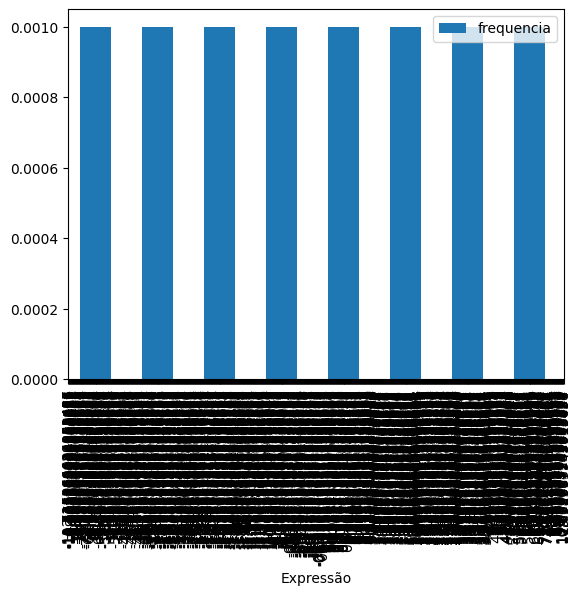

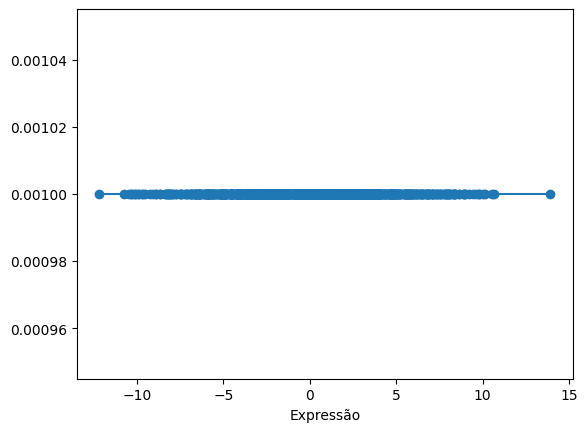

In [78]:
import matplotlib.pyplot as plt

#Gerando grafico de expressão -> Gráfico de barras
expressao.plot(kind="bar")
plt.show()

#Gerando grafico de expressão -> Gráfico de linhas

expressao['frequencia'].plot(kind='line', marker='o')
plt.show()



### Número

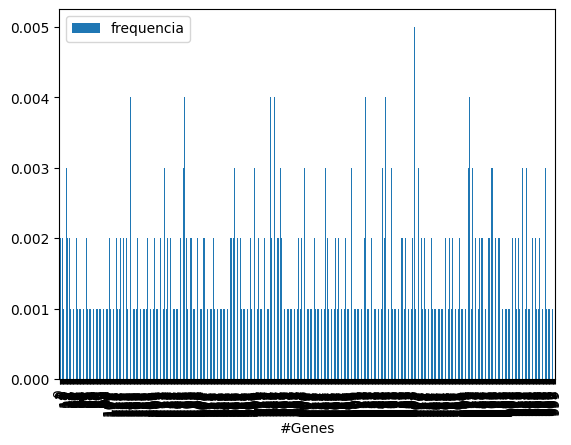

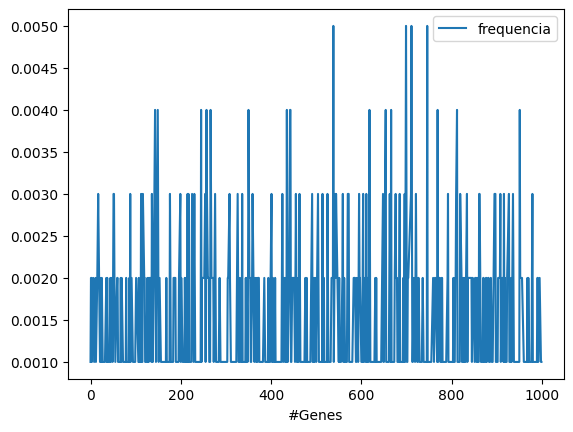

In [80]:
import matplotlib.pyplot as plt

#Gerando grafico de expressão -> Gráfico de barras
genes_1.plot(kind="bar")
plt.show()

#Gerando grafico de expressão -> Gráfico de linhas


genes_1.plot.line()
plt.show()


## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

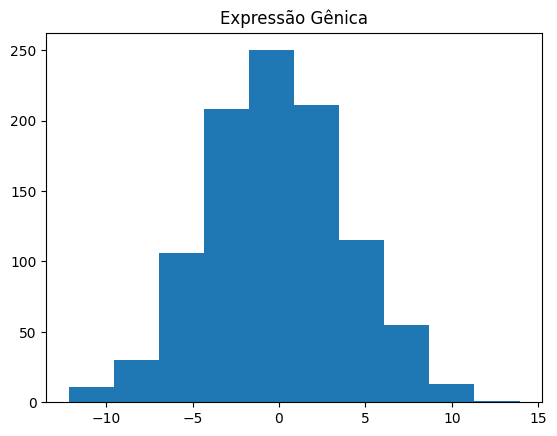

In [86]:
plt.hist(df['Expressão'])
plt.title('Expressão Gênica')
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

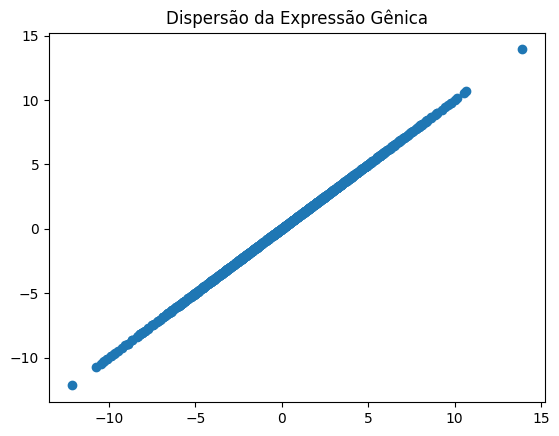

In [88]:
plt.scatter(df['Expressão'], df['Expressão'])
plt.title('Dispersão da Expressão Gênica')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

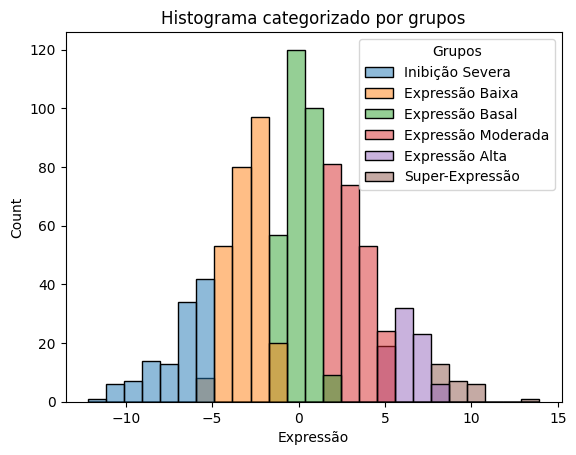

In [94]:
import seaborn as sns
sns.histplot(data=df, x='Expressão', hue='Grupos')
plt.title('Histograma categorizado por grupos')
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

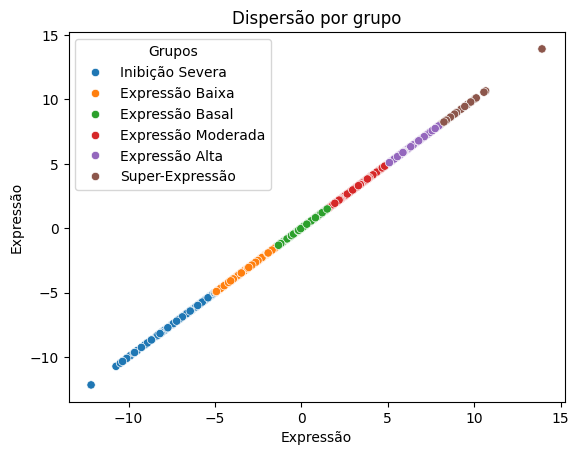

In [96]:
sns.scatterplot(data=df,x='Expressão',y='Expressão',hue='Grupos')
plt.title('Dispersão por grupo')
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|| Discreta|
| % de células positivas|| Contínua|
| Faixa de pH|| Contínua|
| Valor de pH|| Contínua|
| mol/L|| Contínua|
| UFC|| Dscreta|
| D.O.|| Contínua|
| Grupo Sanguíneo|| Nommina|
| Sorologia|| Nominal|

| Variável | Valor |

Número de células positivas -> Discreta

% de células positivas -> Contínua

Faixa de pH -> Ordinal

Valor de pH -> Contínua

mol/L -> Contínua

UFC -> Discreta

D.O. -> Contínua

Grupo Sanguíneo -> Nominal

Sorologia -> Nominal